# AEMO SB3 online RL training notebook

Use this notebook to train an online SB3 policy directly on `AEMOBatteryTradingEnv`, with optional battery-size sweeps and rollout export for offline DT data generation.

In [1]:
from pathlib import Path
import sys
from datetime import datetime

import polars as pl
from stable_baselines3.common.vec_env import DummyVecEnv

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / 'src'))

In [2]:
from aemo_notebook_utils import (
    fetch_and_preprocess_aemo_data,
    fetch_and_preprocess_aemo_scenarios,
    fit_aemo_global_stats,
    make_aemo_env_fns,
    prepare_run_paths,
    resolve_battery_variants,
    train_sb3_model_on_aemo,
    SB3_MODEL_CLASSES
)
from decision import run_sb3_model_on_vec_env
from helper import flatten_episode_data

/usr/local/lib/python3.10/dist-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


## 1. Training configuration

In [ ]:
SB3_MODEL_CLASSES

{'A2C': stable_baselines3.a2c.a2c.A2C,
 'DDPG': stable_baselines3.ddpg.ddpg.DDPG,
 'PPO': stable_baselines3.ppo.ppo.PPO,
 'SAC': stable_baselines3.sac.sac.SAC,
 'TD3': stable_baselines3.td3.td3.TD3}

In [8]:
SCENARIOS = [
    {
        'label': 'sa1_2022_2023',
        'region': 'SA1',
        'start_date': datetime.fromisoformat('2022-01-01'),
        'end_date': datetime.fromisoformat('2023-03-01'),
    },
    {
        'label': 'vic1_2021_2022',
        'region': 'VIC1',
        'start_date': datetime.fromisoformat('2021-01-01'),
        'end_date': datetime.fromisoformat('2022-03-01'),
    },
]

STEP_DURATION = 5 / 60
EPISODE_HOURS = 24*5
ACTION_MODE = 'multi_market'
DEGRADATION_MODE = 'real_world'
DEGRADATION_CHEMISTRY = 'LFP'
DEGRADATION_TEMPERATURE = 30.0

CACHE_DIR = REPO_ROOT / 'src' / 'data' / 'aemo'
OUTPUT_DIR = REPO_ROOT / 'models' / 'aemo_sb3'
RUN_TAG = 'aemo_sb3'
SB3_ALGORITHM = 'TD3'

BATTERY_VARIANTS = [
    {'name': 'small', 'capacity_mwh': 2.0, 'max_power_mw': 1.0, 'init_soc_ratio': 0.5},
    {'name': 'medium', 'capacity_mwh': 10.0, 'max_power_mw': 5.0, 'init_soc_ratio': 0.5},
    {'name': 'large', 'capacity_mwh': 50.0, 'max_power_mw': 25.0, 'init_soc_ratio': 0.5},
]

EPISODES_PER_VARIANT = 2
DEFAULT_MODEL = False
TEST_TIMESTEPS = 40_000
TOTAL_TIMESTEPS = 1000_000
N_TRIALS = 5
N_JOBS = 2
ROLLOUT_EPISODES_PER_VARIANT = 1
DETERMINISTIC_ROLLOUT = True

## 2. Fetch and cache AEMO data

In [4]:
run_paths = prepare_run_paths(output_dir=OUTPUT_DIR, dataset_tag=RUN_TAG)

global_stats, scenario_manifest = fit_aemo_global_stats(
    scenarios=SCENARIOS,
    cache_dir=CACHE_DIR,
    step_duration=STEP_DURATION,
    refresh=False,
)
processed_by_label, _ = fetch_and_preprocess_aemo_scenarios(
    scenarios=SCENARIOS,
    cache_dir=CACHE_DIR,
    step_duration=STEP_DURATION,
    refresh=False,
    fixed_stats=global_stats,
)
combined_processed_data = pl.concat(
    [
        df.with_columns(pl.lit(label).alias('scenario_label'))
        for label, df in processed_by_label.items()
    ],
    how='diagonal_relaxed',
).sort(['SETTLEMENTDATE', 'scenario_label'])
resolved_battery_variants = resolve_battery_variants(BATTERY_VARIANTS)
MAX_STEP = int(round(EPISODE_HOURS / STEP_DURATION))
scenario_manifest

Fetching AEMO data bundle for SA1 from 2022-01-01 to 2023-03-01...
Fetching dispatch price data for SA1 from 2022-01-01 to 2023-03-01...
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
INFO: Compiling data for table DISPATCHREGIONSUM
INFO: Returning DISPATCHREGIONSUM.
Fetched 125587 price records
Fetching FCAS RAISEREG price data for SA1 from 2022-01-01 to 2023-03-01...
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
Fetched 125587 FCAS price records
Fetching FCAS LOWERREG price data for SA1 from 2022-01-01 to 2023-03-01...
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
Fetched 125587 FCAS price records
Fetching FCAS RAISE6SEC price data for SA1 from 2022-01-01 to 2023-03-01...
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
Fetched 125587 FCAS price records
Fetching FCAS LOWER6SEC price data for SA1 from 2022-01-01 to 2023-03-01...
INFO: Compiling data for table DISPATCHPRI

[{'label': 'sa1_2022_2023',
  'region': 'SA1',
  'start_date': datetime.datetime(2022, 1, 1, 0, 0),
  'end_date': datetime.datetime(2023, 3, 1, 0, 0),
  'index': 0},
 {'label': 'vic1_2021_2022',
  'region': 'VIC1',
  'start_date': datetime.datetime(2021, 1, 1, 0, 0),
  'end_date': datetime.datetime(2022, 3, 1, 0, 0),
  'index': 1}]

## 3. Train the SB3 model

/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
[I 2026-04-10 07:36:07,638] A new study created in memory with name: no-name-c5dd8235-007e-4b77-a356-bcade65462f9


Detected list of environment functions; using chunked training.
Tuning hyperparameters for class TD3...


[I 2026-04-10 07:36:59,677] Trial 1 finished with value: -12.931463 and parameters: {'learning_rate': 0.00019818954696189354, 'gamma': 0.9835126241015704, 'tau': 0.015378894428039552, 'batch_size': 64, 'net_arch': 'medium'}. Best is trial 1 with value: -12.931463.
[I 2026-04-10 07:37:03,236] Trial 0 finished with value: -12.690552333333335 and parameters: {'learning_rate': 0.0002677792047019533, 'gamma': 0.9538052323576489, 'tau': 0.0038565779053832115, 'batch_size': 256, 'net_arch': 'medium'}. Best is trial 0 with value: -12.690552333333335.
[I 2026-04-10 07:37:52,344] Trial 2 finished with value: -12.215471999999998 and parameters: {'learning_rate': 0.0007316135339289388, 'gamma': 0.9218458680961048, 'tau': 0.015438315091305655, 'batch_size': 128, 'net_arch': 'small'}. Best is trial 2 with value: -12.215471999999998.
[I 2026-04-10 07:37:58,676] Trial 3 finished with value: -13.319617999999998 and parameters: {'learning_rate': 0.0003221784092948314, 'gamma': 0.9787883235095636, 'tau':

Best trial for class TD3:
{'learning_rate': 0.0007316135339289388, 'gamma': 0.9218458680961048, 'tau': 0.015438315091305655, 'batch_size': 128, 'net_arch': 'small'}


/usr/local/lib/python3.10/dist-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.10/dist-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/pytho

Training the model with the best hyperparameters...
Chunk 1: envs=6, steps=1000000
training complete.


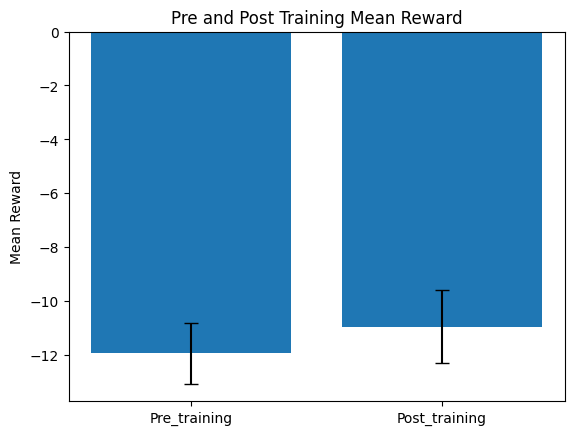

/code/models/aemo_sb3/td3_aemo_model.zip


{'Pre_training': {'mean_reward': np.float64(-11.958346400000002),
  'std_reward': np.float64(1.1159040539717742)},
 'Post_training': {'mean_reward': np.float64(-10.970097999999998),
  'std_reward': np.float64(1.3585540792881228)}}

In [9]:
model, eval_result = train_sb3_model_on_aemo(
    processed_data=combined_processed_data,
    algorithm=SB3_ALGORITHM,
    battery_variants=resolved_battery_variants,
    episodes_per_variant=EPISODES_PER_VARIANT,
    max_step=MAX_STEP,
    step_duration=STEP_DURATION,
    action_mode=ACTION_MODE,
    degradation_mode=DEGRADATION_MODE,
    degradation_chemistry=DEGRADATION_CHEMISTRY,
    degradation_temperature=DEGRADATION_TEMPERATURE,
    random_episode_start=True,
    test_timesteps=TEST_TIMESTEPS,
    total_timesteps=TOTAL_TIMESTEPS,
    n_trials=N_TRIALS,
    n_jobs=N_JOBS,
    default_model=DEFAULT_MODEL,
)

MODEL_PATH = run_paths['output_dir'] / f'{SB3_ALGORITHM.lower()}_aemo_model.zip'
model.save(MODEL_PATH)
print(MODEL_PATH)
eval_result

## 4. Export rollout logs for evaluation or offline DT data

In [ ]:
rollout_env_fns = make_aemo_env_fns(
    processed_data=combined_processed_data,
    battery_variants=resolved_battery_variants,
    episodes_per_variant=ROLLOUT_EPISODES_PER_VARIANT,
    max_step=MAX_STEP,
    step_duration=STEP_DURATION,
    action_mode=ACTION_MODE,
    degradation_mode=DEGRADATION_MODE,
    degradation_chemistry=DEGRADATION_CHEMISTRY,
    degradation_temperature=DEGRADATION_TEMPERATURE,
    random_episode_start=True,
)
rollout_vec_env = DummyVecEnv(rollout_env_fns)
try:
    episode_data = run_sb3_model_on_vec_env(model, rollout_vec_env, deterministic=DETERMINISTIC_ROLLOUT, max_steps=MAX_STEP)
finally:
    rollout_vec_env.close()

rollout_df = flatten_episode_data(episode_data)
rollout_path = run_paths['raw_dir'] / f'{SB3_ALGORITHM.lower()}_rollouts.parquet'
rollout_df.write_parquet(rollout_path)
print(rollout_path)
rollout_df.head()

## 5. Optional next step

Use the exported SB3 rollout parquet inside `aemo_simrun.ipynb` by adding it to the `BEHAVIOR_RUNS` config as an SB3 behavior source, or merge it into the DT dataset manually.